In [1]:
import numpy as np
import pandas as pd

In [6]:
import seaborn as sns

In [3]:
df = pd.read_csv(r'placement.csv')

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [5]:
df.columns.tolist()

['cgpa', 'placement_exam_marks', 'placed']

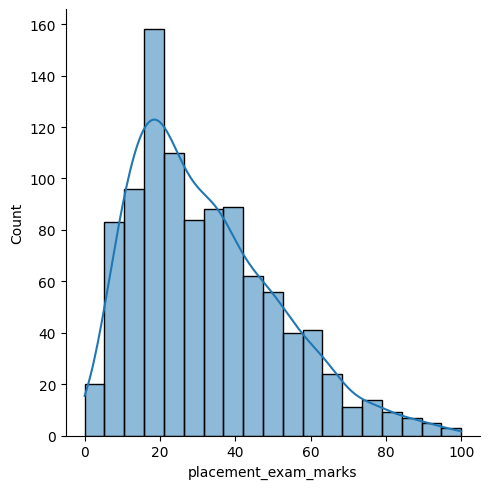

In [11]:
sns.displot(x ='placement_exam_marks', data = df,kde =True)

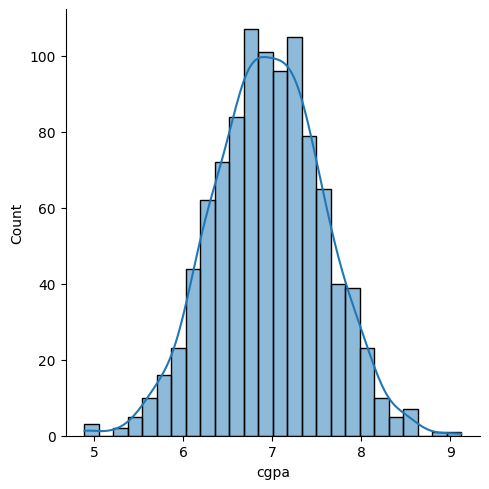

In [12]:
sns.displot(x ='cgpa', data = df,kde =True)

In [15]:
min = df['cgpa'].mean() - 3* df['cgpa'].std()
max = df['cgpa'].mean()+3*df['cgpa'].std()

In [16]:
min, max

(np.float64(5.113546374602832), np.float64(8.808933625397168))

In [17]:
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Min value of cgpa 4.89
Max value of cgpa 9.12


In [20]:
outliers = df[(df['cgpa']>8.8) | (df['cgpa']< 5.11)]
outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### TRIMMING

In [21]:
new_df = df[(df['cgpa']<8.8) & (df['cgpa']> 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


### aprroach 2 calculate z score

In [25]:
df['cgpa_zscore']= (df['cgpa']- df['cgpa'].mean())/df['cgpa'].std()
df['cgpa_zscore']

0      0.371425
1      0.809810
2      0.939701
3     -0.878782
4      0.436371
         ...   
995    3.099150
996    3.505062
997   -3.362960
998    2.693239
999   -3.346724
Name: cgpa_zscore, Length: 1000, dtype: float64

In [26]:
df[df['cgpa_zscore'] > 3], df[df['cgpa_zscore'] < -3]

(     cgpa  placement_exam_marks  placed  cgpa_zcore  cgpa_zscore
 995  8.87                  44.0       1    3.099150     3.099150
 996  9.12                  65.0       1    3.505062     3.505062,
      cgpa  placement_exam_marks  placed  cgpa_zcore  cgpa_zscore
 485  4.92                  44.0       1   -3.314251    -3.314251
 997  4.89                  34.0       0   -3.362960    -3.362960
 999  4.90                  10.0       1   -3.346724    -3.346724)

In [27]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

### CAPPING

In [28]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [29]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

### np.where(condition, value_if_true, value_if_false)